Importing Libraries

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, roc_curve, auc

Load Dataset

In [2]:
data = pd.read_csv('bank.csv')


EDA

In [3]:
data.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


In [5]:
data.describe()

,age,balance,day,duration,campaign,pdays,previous
count,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000
mean,41.231948,1528.538524,15.658036,371.993818,2.508421,51.330407,0.832557
std,11.913369,3225.413326,8.420740,347.128386,2.722077,108.758282,2.292007
min,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,32.000000,122.000000,8.000000,138.000000,1.000000,-1.000000,0.000000
50%,39.000000,550.000000,15.000000,255.000000,2.000000,-1.000000,0.000000
75%,49.000000,1708.000000,22.000000,496.000000,3.000000,20.750000,1.000000
max,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000


In [6]:
data.shape

(11162, 17)

In [7]:
data['deposit'].value_counts(normalize=True)

deposit
no     0.52616
yes    0.47384
Name: proportion, dtype: float64

EDA: Univariate Analysis

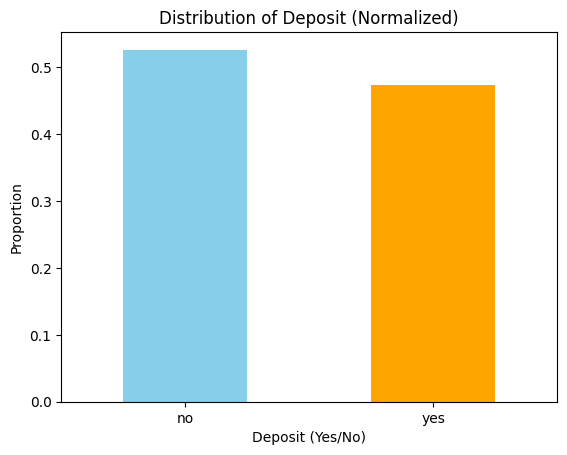

In [8]:
import matplotlib.pyplot as plt

deposit_counts = data['deposit'].value_counts(normalize=True)

deposit_counts.plot(kind='bar', color=['skyblue', 'orange'])

plt.title('Distribution of Deposit (Normalized)')
plt.xlabel('Deposit (Yes/No)')
plt.ylabel('Proportion')
plt.xticks(rotation=0) 
plt.show()

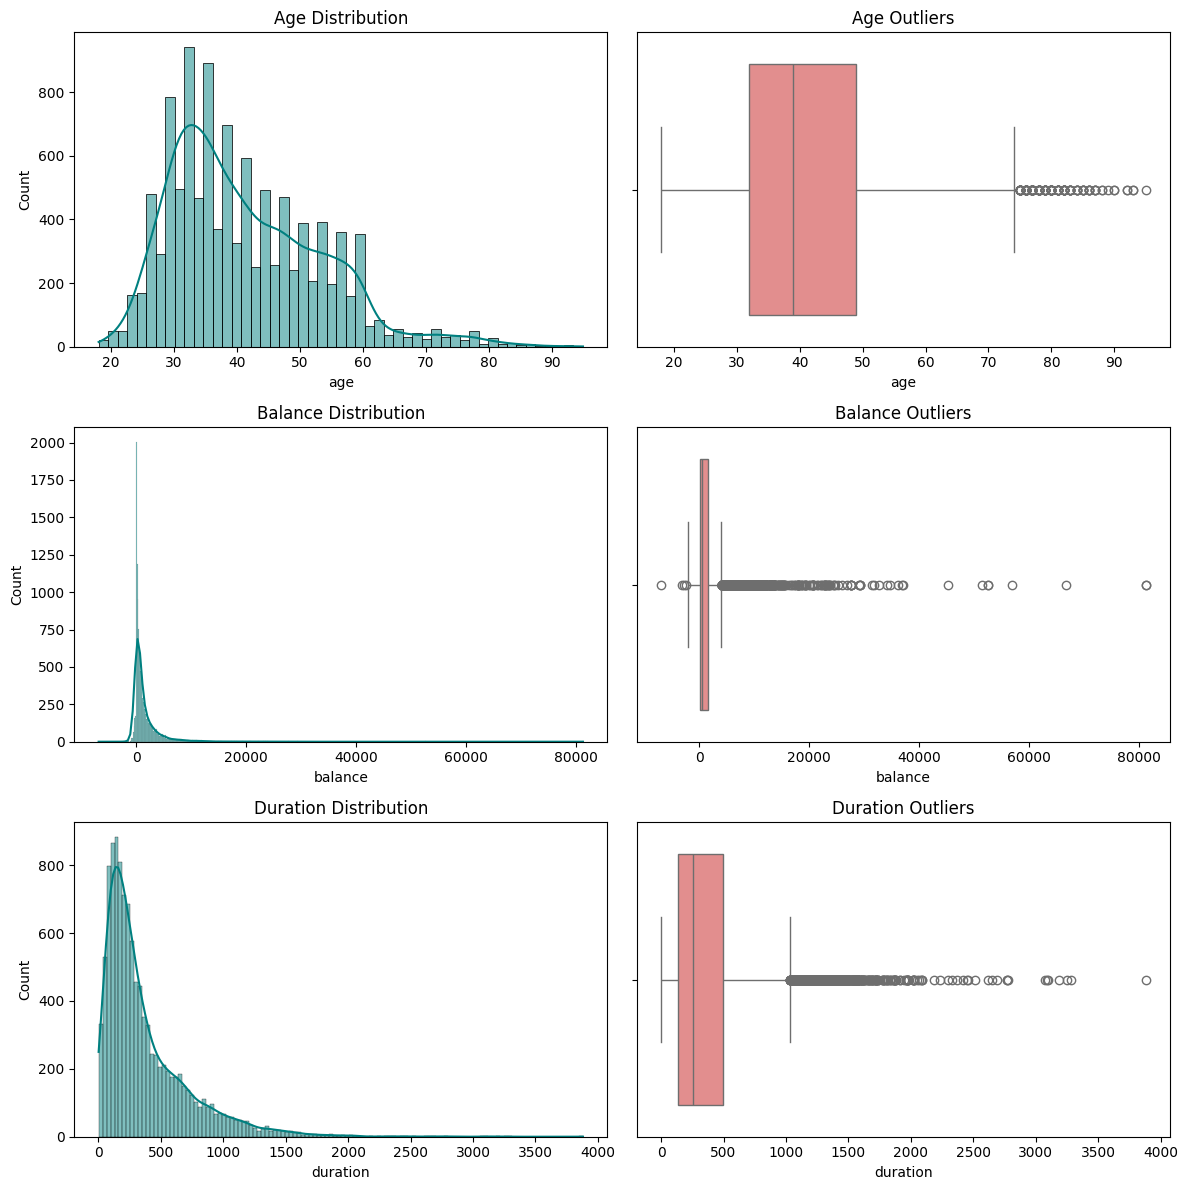

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = ['age', 'balance', 'duration', ]

fig, axes = plt.subplots(len(num_cols), 2, figsize=(12, 4 * len(num_cols)))

for i, col in enumerate(num_cols):
    # Histogram: Check for Skewness
    sns.histplot(data[col], kde=True, ax=axes[i, 0], color='teal')
    axes[i, 0].set_title(f'{col.capitalize()} Distribution')
    
    # Boxplot: Detect Outliers
    sns.boxplot(x=data[col], ax=axes[i, 1], color='lightcoral')
    axes[i, 1].set_title(f'{col.capitalize()} Outliers')

plt.tight_layout()
plt.show()


--- Frequency Distribution: JOB ---
job
management       2566
blue-collar      1944
technician       1823
admin.           1334
services          923
retired           778
self-employed     405
student           360
unemployed        357
entrepreneur      328
housemaid         274
unknown            70
Name: count, dtype: int64


--- Frequency Distribution: MARITAL ---
marital
married     6351
single      3518
divorced    1293
Name: count, dtype: int64


--- Frequency Distribution: EDUCATION ---
education
secondary    5476
tertiary     3689
primary      1500
unknown       497
Name: count, dtype: int64




C:\Users\david\AppData\Local\Temp\ipykernel_24484\2141542917.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, y=col, ax=axes[i], order=order, palette='viridis')
C:\Users\david\AppData\Local\Temp\ipykernel_24484\2141542917.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, y=col, ax=axes[i], order=order, palette='viridis')
C:\Users\david\AppData\Local\Temp\ipykernel_24484\2141542917.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, y=col, ax=axes[i], order=order, palette='viridis')


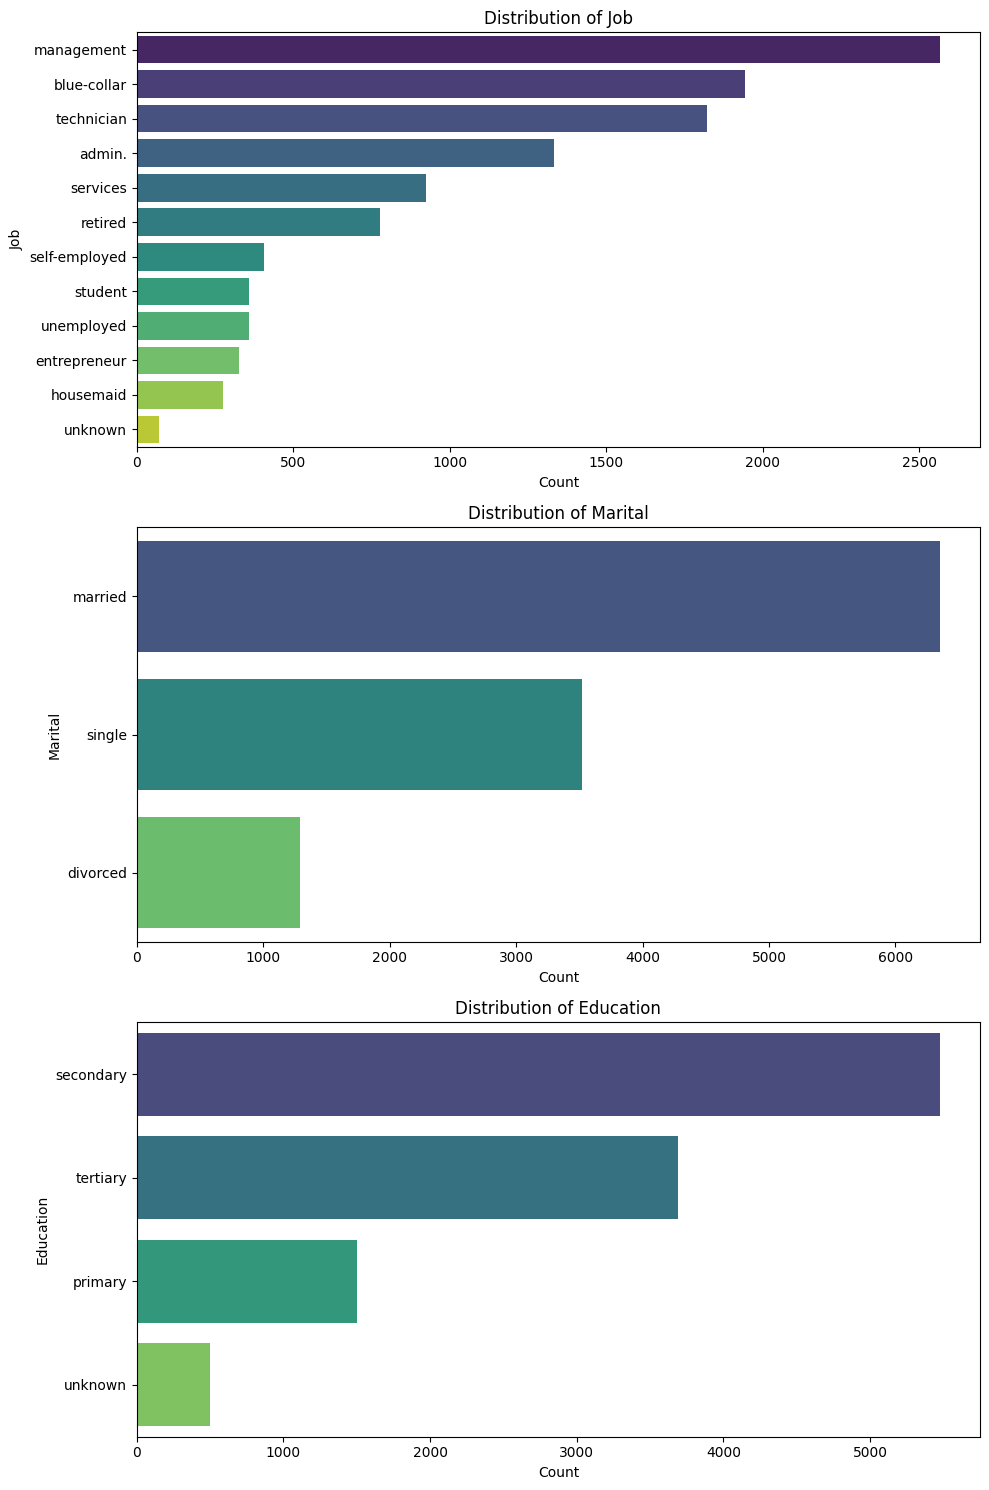

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

cat_cols = ['job', 'marital', 'education']

for col in cat_cols:
    print(f"--- Frequency Distribution: {col.upper()} ---")
    print(data[col].value_counts())
    print("\n")

fig, axes = plt.subplots(len(cat_cols), 1, figsize=(10, 5 * len(cat_cols)))

for i, col in enumerate(cat_cols):
    order = data[col].value_counts().index
    
    sns.countplot(data=data, y=col, ax=axes[i], order=order, palette='viridis')
    axes[i].set_title(f'Distribution of {col.capitalize()}')
    axes[i].set_xlabel('Count')
    axes[i].set_ylabel(col.capitalize())

plt.tight_layout()
plt.show()


C:\Users\david\AppData\Local\Temp\ipykernel_24484\3331326260.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='deposit', y='age', palette='Set2')


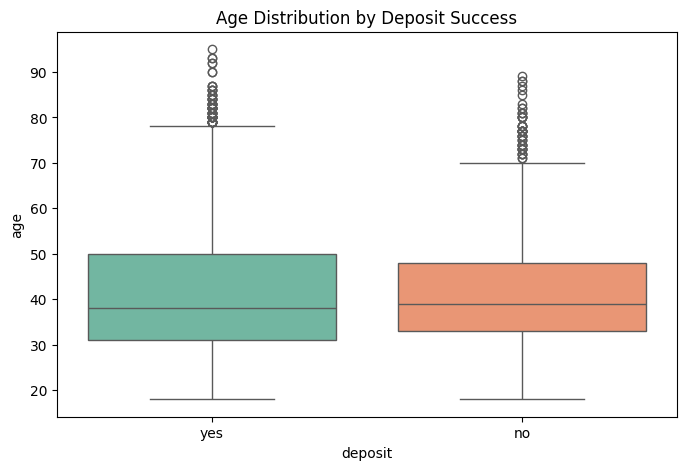

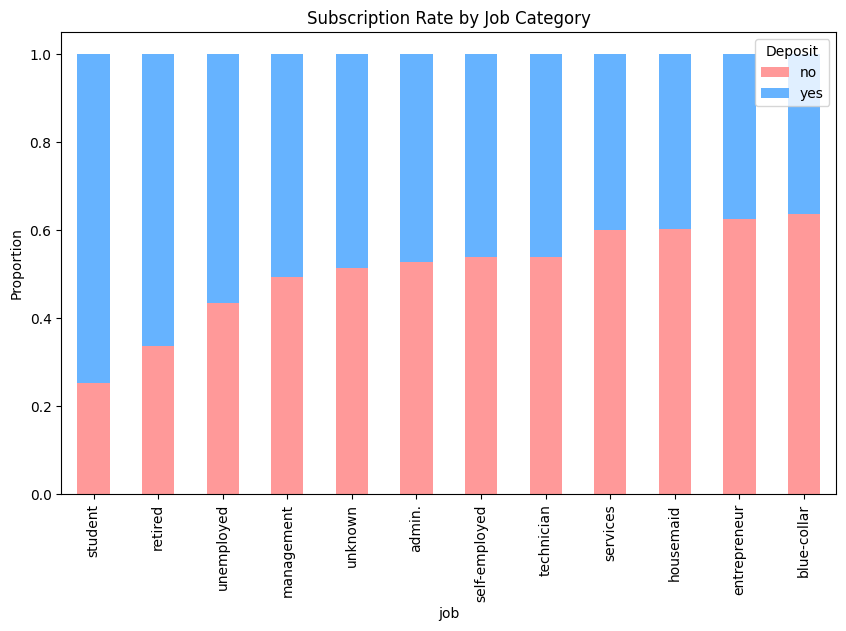

C:\Users\david\AppData\Local\Temp\ipykernel_24484\3331326260.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=data, x='deposit', y='duration', palette='Pastel1')


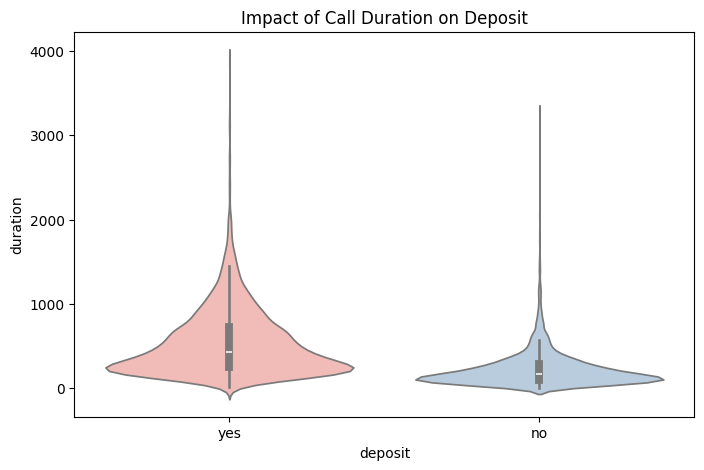

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Numerical: Age vs. Deposit
plt.figure(figsize=(8, 5))
sns.boxplot(data=data, x='deposit', y='age', palette='Set2')
plt.title('Age Distribution by Deposit Success')
plt.show()

# 2. Categorical: Job vs. Deposit
job_deposit_dist = data.groupby('job')['deposit'].value_counts(normalize=True).unstack()
job_deposit_dist.sort_values(by='yes', ascending=False).plot(kind='bar', stacked=True, figsize=(10, 6), color=['#ff9999','#66b3ff'])
plt.title('Subscription Rate by Job Category')
plt.ylabel('Proportion')
plt.legend(title='Deposit', loc='upper right')
plt.show()

plt.figure(figsize=(8, 5))
sns.violinplot(data=data, x='deposit', y='duration', palette='Pastel1')
plt.title('Impact of Call Duration on Deposit')
plt.show()


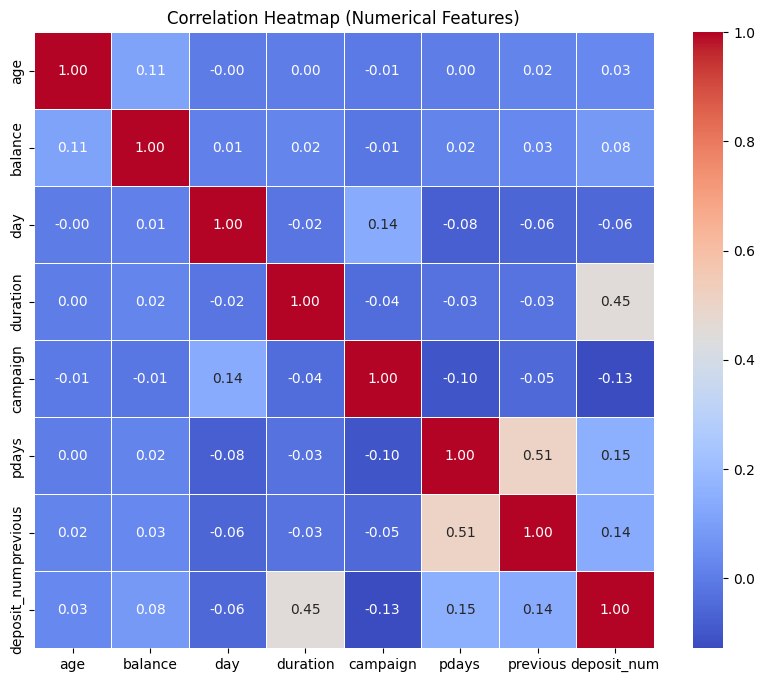

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

# Map target to numeric for correlation purposes
data['deposit_num'] = data['deposit'].map({'yes': 1, 'no': 0})

# Calculate correlation matrix
corr_matrix = data.select_dtypes(include=['number']).corr()

# Plot Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap (Numerical Features)')
plt.show()


# Summary of Heatmap

The heatmap reveals which numerical variables have the strongest relationship with the goal of getting a customer to subscribe (deposit_num). Here is what we can "distill" from the correlations:
1. The "Golden" Feature: duration (0.45)
This is the most important finding. There is a moderate positive correlation (0.45) between call duration and the deposit.
What it means: The longer a person stays on the phone with the bank representative, the much more likely they are to subscribe. This is likely your strongest predictor for any machine learning model you build.
2. The Relationship Between pdays and previous (0.51)
There is a stronger correlation (0.51) between these two features.
What it means: These are related to past marketing campaigns. If a customer was contacted previously, they are highly likely to have a recorded number of days passed since the last contact. This is called multicollinearity, and it tells us these two features provide similar information.
3. Weak or Negligible Influences
age (0.03) and balance (0.08): These have almost zero linear correlation with subscribing. This confirms what we saw in your boxplot earlier: while some older people subscribe, age by itself doesn't move the needle much.
campaign (-0.13): This has a negative correlation. It suggests that the more times you contact a person during this campaign, the less likely they are to subscribe (perhaps due to annoyance or "marketing fatigue").


# Data Preprocessing

Defining Features

In [13]:
numeric_features = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
categorical_features = [
    'job', 'marital', 'education', 'default', 'housing', 'loan', 'month', 'poutcome', 'contact'
]
target = "deposit_num"

X = data[categorical_features + numeric_features]
y = data[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42)


Preprocessing

In [14]:
# Preprocessing
categorical_transformer = OneHotEncoder(handle_unknown='ignore')
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', categorical_transformer, categorical_features),
        ('num', 'passthrough', numeric_features)
    ])

# Apply preprocessing first
X_train_pre = preprocessor.fit_transform(X_train)
X_test_pre = preprocessor.transform(X_test)

# Apply SMOTE on preprocessed training data
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_pre, y_train)

In [15]:
# Ensemble Models
rf = RandomForestClassifier(random_state=42)
gb = GradientBoostingClassifier(random_state=42)
lr = LogisticRegression(max_iter=1000)

In [16]:
# Stacking
stacking = StackingClassifier(
    estimators=[('rf', rf), ('gb', gb)],
    final_estimator=lr
)

In [17]:
# Model
models = {
    "Random Forest": rf,
    "Gradient Boosting": gb,
    "Stacking": stacking
}


# Train & Evaluate

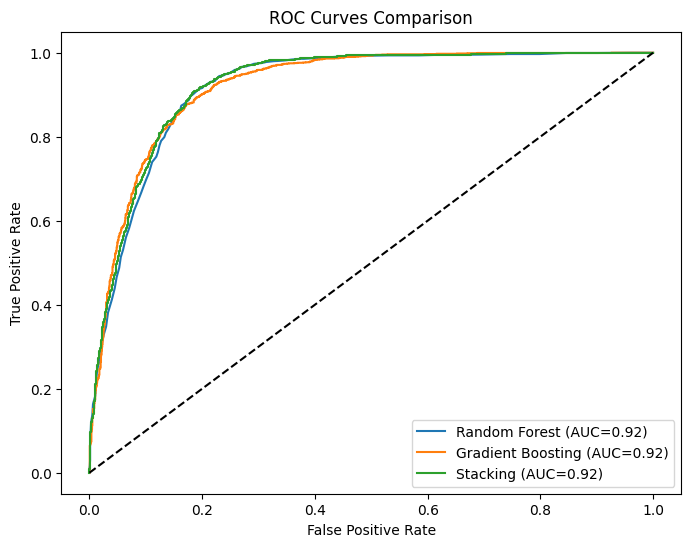


Random Forest:
  ROC-AUC: 0.919
  Precision: 0.825
  Recall: 0.878
  F1: 0.851

Gradient Boosting:
  ROC-AUC: 0.921
  Precision: 0.828
  Recall: 0.858
  F1: 0.843

Stacking:
  ROC-AUC: 0.923
  Precision: 0.824
  Recall: 0.870
  F1: 0.846


In [18]:

results = {}
plt.figure(figsize=(8,6))

for name, model in models.items():
    model.fit(X_train_res, y_train_res)
    y_pred = model.predict(X_test_pre)
    y_proba = model.predict_proba(X_test_pre)[:,1]
    
    # Metrics
    results[name] = {
        "ROC-AUC": roc_auc_score(y_test, y_proba),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred)
    }
    
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc(fpr,tpr):.2f})")

# Plot ROC curves
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves Comparison")
plt.legend()
plt.show()

# Print results
for model, metrics in results.items():
    print(f"\n{model}:")
    for metric, value in metrics.items():
        print(f"  {metric}: {value:.3f}")

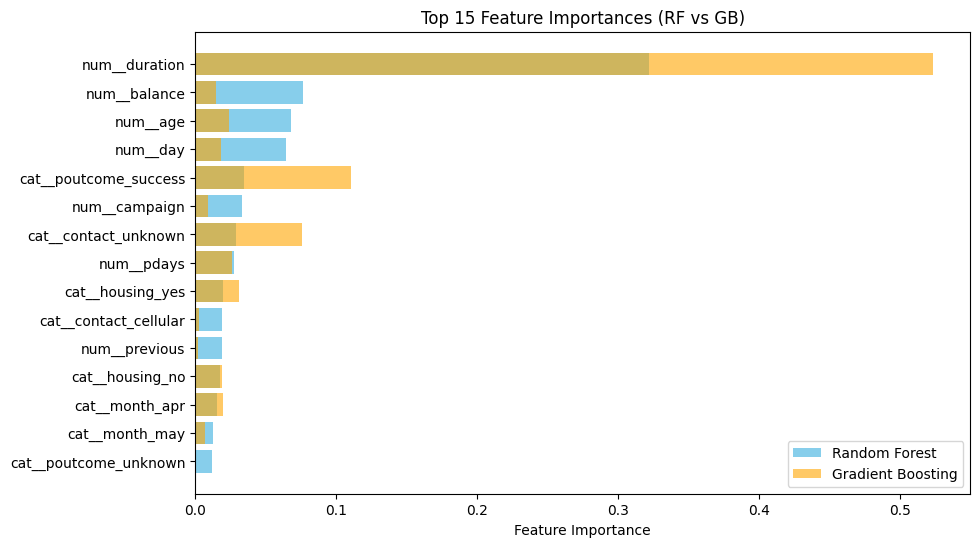

In [19]:
# Get feature names after preprocessing
feature_names = preprocessor.get_feature_names_out()

# Feature importances
rf_importances = rf.feature_importances_
gb_importances = gb.feature_importances_

# Create DataFrame
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'RandomForest': rf_importances,
    'GradientBoosting': gb_importances
})

# Sort by RF importance for plotting
importance_df = importance_df.sort_values(by='RandomForest', ascending=False).head(15)

# Plot
plt.figure(figsize=(10,6))
plt.barh(importance_df['Feature'], importance_df['RandomForest'], color='skyblue', label='Random Forest')
plt.barh(importance_df['Feature'], importance_df['GradientBoosting'], color='orange', alpha=0.6, label='Gradient Boosting')
plt.xlabel("Feature Importance")
plt.title("Top 15 Feature Importances (RF vs GB)")
plt.legend()
plt.gca().invert_yaxis()
plt.show()



In [20]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
import numpy as np

# Define CV strategy
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Evaluate each model with ROC-AUC
for name, model in models.items():
    scores = cross_val_score(model, X_train_res, y_train_res, 
                             cv=cv, scoring='roc_auc')
    print(f"{name} CV ROC-AUC: {np.mean(scores):.3f} ± {np.std(scores):.3f}")


Random Forest CV ROC-AUC: 0.924 ± 0.008
Gradient Boosting CV ROC-AUC: 0.923 ± 0.008
Stacking CV ROC-AUC: 0.927 ± 0.009


# SHAP Analysis
SHAP (SHapley Additive exPlanations) provides a unified approach to explain the output of any machine learning model. It connects optimal credit allocation with local explanations using game-theoretic Shapley values.


## SHAP - Random Forest


In [ ]:
import shap
import matplotlib.pyplot as plt

# Create SHAP explainer for Random Forest
rf_explainer = shap.TreeExplainer(rf)
rf_shap_values = rf_explainer.shap_values(X_test_pre)

# Get feature names
feature_names = preprocessor.get_feature_names_out()


In [ ]:
# SHAP Summary Plot (Beeswarm) - shows feature importance + direction of impact
plt.figure(figsize=(12, 8))
shap.summary_plot(rf_shap_values[:, :, 1], X_test_pre, feature_names=feature_names, show=False)
plt.title("SHAP Summary Plot - Random Forest (Deposit = Yes)", fontsize=14)
plt.tight_layout()
plt.show()


In [ ]:
# SHAP Bar Plot - Global feature importance (mean |SHAP value|)
plt.figure(figsize=(12, 8))
shap.summary_plot(rf_shap_values[:, :, 1], X_test_pre, feature_names=feature_names, plot_type="bar", show=False)
plt.title("SHAP Feature Importance (Mean |SHAP Value|) - Random Forest", fontsize=14)
plt.tight_layout()
plt.show()


## SHAP - Gradient Boosting


In [ ]:
# Create SHAP explainer for Gradient Boosting
gb_explainer = shap.TreeExplainer(gb)
gb_shap_values = gb_explainer.shap_values(X_test_pre)


In [ ]:
# SHAP Summary Plot - Gradient Boosting
plt.figure(figsize=(12, 8))
shap.summary_plot(gb_shap_values, X_test_pre, feature_names=feature_names, show=False)
plt.title("SHAP Summary Plot - Gradient Boosting (Deposit = Yes)", fontsize=14)
plt.tight_layout()
plt.show()


In [ ]:
# SHAP Bar Plot - Gradient Boosting
plt.figure(figsize=(12, 8))
shap.summary_plot(gb_shap_values, X_test_pre, feature_names=feature_names, plot_type="bar", show=False)
plt.title("SHAP Feature Importance (Mean |SHAP Value|) - Gradient Boosting", fontsize=14)
plt.tight_layout()
plt.show()


## SHAP Dependence Plots
Dependence plots show how a single feature affects the model's predictions. The color indicates interaction with another feature.


In [ ]:
# Find the index of 'duration' in feature names
duration_idx = list(feature_names).index('num__duration')

# SHAP Dependence Plot for Duration (the strongest predictor)
plt.figure(figsize=(10, 6))
shap.dependence_plot(duration_idx, gb_shap_values, X_test_pre, feature_names=feature_names, show=False)
plt.title("SHAP Dependence Plot: Duration vs SHAP Value (Gradient Boosting)", fontsize=14)
plt.tight_layout()
plt.show()


In [ ]:
# SHAP Dependence Plot for Balance
balance_idx = list(feature_names).index('num__balance')

plt.figure(figsize=(10, 6))
shap.dependence_plot(balance_idx, gb_shap_values, X_test_pre, feature_names=feature_names, show=False)
plt.title("SHAP Dependence Plot: Balance vs SHAP Value (Gradient Boosting)", fontsize=14)
plt.tight_layout()
plt.show()


## SHAP Waterfall Plot - Individual Prediction Explanation
Explains why a specific customer was predicted to subscribe (or not). Shows which features pushed the prediction higher or lower.


In [ ]:
# Waterfall plot for a single prediction (first test sample)
# Using Gradient Boosting SHAP values
shap_explanation = shap.Explanation(
    values=gb_shap_values[0],
    base_values=gb_explainer.expected_value,
    data=X_test_pre[0] if hasattr(X_test_pre, '__getitem__') else X_test_pre.toarray()[0],
    feature_names=feature_names
)

plt.figure(figsize=(12, 8))
shap.waterfall_plot(shap_explanation, max_display=15, show=False)
plt.title("SHAP Waterfall - Why This Customer Was Predicted to Subscribe/Not Subscribe", fontsize=12)
plt.tight_layout()
plt.show()


In [ ]:
# Force plot for the same individual prediction
shap.initjs()
shap.force_plot(
    gb_explainer.expected_value,
    gb_shap_values[0],
    X_test_pre[0] if hasattr(X_test_pre, '__getitem__') else X_test_pre.toarray()[0],
    feature_names=feature_names,
    matplotlib=True
)
plt.title("SHAP Force Plot - Individual Prediction", fontsize=12)
plt.tight_layout()
plt.show()


## SHAP Interpretation Summary

**Key Takeaways from SHAP Analysis:**

1. **Duration** is the most impactful feature — longer call durations strongly push the prediction toward deposit subscription
2. **Previous campaign outcome (poutcome)** — customers with a successful previous outcome are far more likely to subscribe
3. **Contact** method and **housing loan status** also play significant roles
4. **Age and Balance** have moderate, nuanced effects — the dependence plots reveal non-linear relationships
5. **Campaign count** (number of contacts) has a negative effect — over-contacting reduces conversion probability

These SHAP insights go beyond simple feature importance by showing the **direction** and **magnitude** of each feature's contribution to individual predictions, enabling targeted marketing strategies.
